# Cricket Parallel work flow without LLM

**Create a flow diagram to illustrate how a parallel workflow works, including key cricket performance metrics such as Strike Rate, Balls per Boundary, and Boundary Percentage.**

In [22]:
#Define Library
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from google import genai

In [23]:
class CricketParrel(TypedDict):
    runs : int
    balls : int
    fours : int
    sixes : int

    sr : float
    bpb : float
    boundary_percent : float
    summary : str
    

In [24]:
def Calculate_SR(state:CricketParrel) :
    sr=round((state['runs']/state['balls'])/100)
    return {'sr':sr}

In [25]:
def Calculate_bpb(state:CricketParrel) :
    bpb=round(state['balls']/(state['fours']+state['sixes']))

    #return only required key not full state
    return {'bpb':bpb}

In [26]:
def Calculate_boundary_percent(state:CricketParrel)  :
    boundary_percent=round((((state['fours']*4)+(state['sixes']*6))/state['runs'])*100)
    return {'boundary_percent':boundary_percent}

In [27]:
def Calculate_summary(state:CricketParrel)  :
    summary = f"""
    Strike Rate - {state['sr']} \n
    Balls per boundart -{state['bpb']} \n
    Boundary percent - {state['boundary_percent']} 
    """
    return {'summary':summary}

In [28]:
#Define graph
graph=StateGraph(CricketParrel) 

#add notes to the graph
graph.add_node('Calculate_SR',Calculate_SR)
graph.add_node('Calculate_bpb',Calculate_bpb)
graph.add_node('Calculate_boundary_percent',Calculate_boundary_percent)
graph.add_node('Calculate_summary',Calculate_summary)

#add edges to the graph
graph.add_edge(START,'Calculate_SR')
graph.add_edge(START,'Calculate_bpb')
graph.add_edge(START,'Calculate_boundary_percent')

graph.add_edge('Calculate_SR','Calculate_summary')
graph.add_edge('Calculate_bpb','Calculate_summary')
graph.add_edge('Calculate_boundary_percent','Calculate_summary')

graph.add_edge('Calculate_summary',END)

#compile the graph
workflow=graph.compile()

#execute the graph
initial_state = {'runs':56,'balls':21,'fours':8,'sixes':3}
final_state=workflow.invoke(initial_state)
print(final_state['summary'])


    Strike Rate - 0 

    Balls per boundart -2 

    Boundary percent - 89 
    


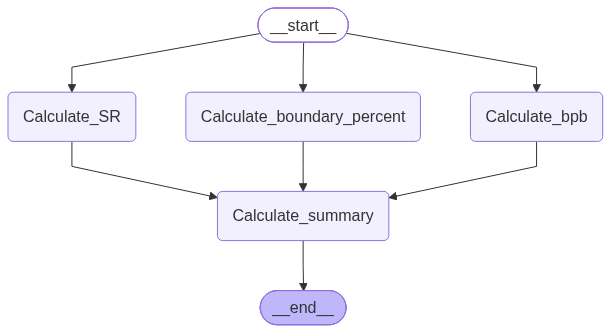

In [29]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())